# **Setting Environment**
1. Jalankan _uv init namaproject_
2. Jalankan _.venv\Scripts\activate_ utk aktivasi env
3. Buat file _requirements.txt_ isinya nama-nama libraries
4. Jalankan _uv add requirements.txt_ untuk menginstall library ke env
5. Jalankan _uv sync_ untuk sinkronasi lib di env dengan lib global di PC/Laptop

# **Import Library**

In [ ]:
import pandas as pd
import numpy as np
import re
import nltk
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import openpyxl

from collections import Counter

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    auc
)

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC

from xgboost import XGBClassifier

from wordcloud import WordCloud

nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ADMIN\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


True

# **Load Dataset**

In [2]:
dset = pd.read_excel('cyberbullying_tweets.xlsx',sheet_name='Sheet1')
dset.head()
# source : https://www.kaggle.com/datasets/andrewmvd/cyberbullying-classification

,tweet_text,cyberbullying_type
0,"In other words #katandandre, your food was cra...",not_cyberbullying
1,Why is #aussietv so white? #MKR #theblock #ImA...,not_cyberbullying
2,@XochitlSuckkks a classy whore? Or more red ve...,not_cyberbullying
3,"@Jason_Gio meh. :P thanks for the heads up, b...",not_cyberbullying
4,@RudhoeEnglish This is an ISIS account pretend...,not_cyberbullying


In [3]:
# Dekripsi
dset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47692 entries, 0 to 47691
Data columns (total 2 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   tweet_text          47688 non-null  object
 1   cyberbullying_type  47692 non-null  object
dtypes: object(2)
memory usage: 745.3+ KB


In [4]:
# Cek missing values
missing = pd.DataFrame({
    'Missing': dset.isnull().sum(),
    'Percentage': dset.isnull().mean() * 100
})

missing[missing['Missing'] > 0]

,Missing,Percentage
tweet_text,4,0.008387


In [5]:
# Makes sure missing values
dset[dset['tweet_text'].isnull()]

,tweet_text,cyberbullying_type
26865,NaN,other_cyberbullying
41106,NaN,ethnicity
41124,NaN,ethnicity
42050,NaN,ethnicity


In [6]:
# Hapus baris missing values 
dset.dropna(inplace=True)

In [ ]:
dset['cat_cyberbullying'] = dset['cyberbullying_type'].map({
    'age' : 0,
    'ethnicity' : 1,
    'gender' : 2,
    'not_cyberbullying' : 3,
    'other_cyberbullying' : 4,
    'religion' : 5
})

dset["cat_bullying"] = np.where(dset['cat_cyberbullying'] == 3, "Not bullying", "Bullying")

In [12]:
dset

,tweet_text,cyberbullying_type,cat_cyberbullying,cat_bullying
0,"In other words #katandandre, your food was cra...",not_cyberbullying,3,Not bullying
1,Why is #aussietv so white? #MKR #theblock #ImA...,not_cyberbullying,3,Not bullying
2,@XochitlSuckkks a classy whore? Or more red ve...,not_cyberbullying,3,Not bullying
3,"@Jason_Gio meh. :P thanks for the heads up, b...",not_cyberbullying,3,Not bullying
4,@RudhoeEnglish This is an ISIS account pretend...,not_cyberbullying,3,Not bullying
...,...,...,...,...
47687,"Black ppl aren't expected to do anything, depe...",ethnicity,1,Bullying
47688,Turner did not withhold his disappointment. Tu...,ethnicity,1,Bullying
47689,I swear to God. This dumb nigger bitch. I have...,ethnicity,1,Bullying
47690,Yea fuck you RT @therealexel: IF YOURE A NIGGE...,ethnicity,1,Bullying


# **EDA**

In [8]:
cat_bullying = dset.groupby(['cyberbullying_type'])['tweet_text'].count()\
    .reset_index(name='count')\
    .assign(
        pct = lambda x:x['count']/x['count'].sum(),
    )

cat_bullying

,cyberbullying_type,count,pct
0,age,7992,0.167589
1,ethnicity,7958,0.166876
2,gender,7973,0.167191
3,not_cyberbullying,7945,0.166604
4,other_cyberbullying,7822,0.164024
5,religion,7998,0.167715


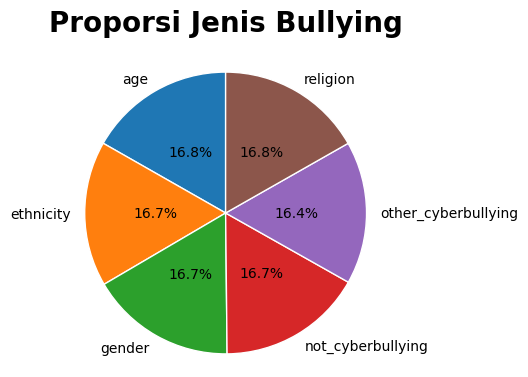

In [10]:
plt.figure(figsize=(4,4))

plt.pie(
    cat_bullying['count'],
    labels=cat_bullying['cyberbullying_type'],
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops={'edgecolor': 'white'},
    pctdistance=0.5
)

plt.title('Proporsi Jenis Bullying', fontsize=20, fontweight='bold', loc='center', pad=20)
plt.axis('equal')
plt.show()

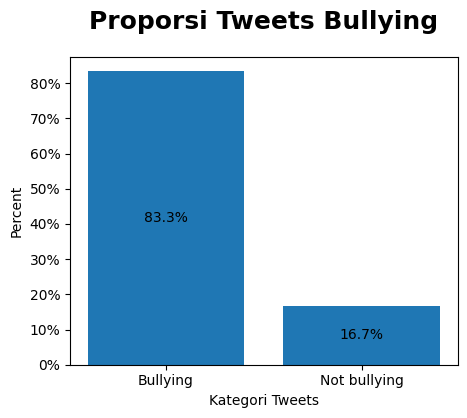

In [46]:
cat_bullying1 = \
    dset.groupby(['cat_bullying'])['cat_bullying']\
        .value_counts()\
        .reset_index(name='count')\
        .assign(pct = lambda x:x['count']/x['count'].sum())

fig, ax = plt.subplots(figsize=(5,4))
ax.set_title('Proporsi Tweets Bullying', fontsize=18, fontweight='bold', pad=20)
bars = ax.bar(cat_bullying1['cat_bullying'],cat_bullying1['pct'])
ax.bar_label(bars,labels=(cat_bullying1['pct']*100).round(1).astype(str) + '%',label_type='center')
ax.set_xlabel('Kategori Tweets', fontsize=10)
ax.set_ylabel('Percent', fontsize=10)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1))
plt.show()

# **Cleaning Data Text**

1. Step 1 : Lowercase / UpperCase
2. Step 2 : Punctuation Removal
3. Step 3 : HTML Code and URL Links Removal
4. Step 4 : Spell Checks
5. Step 5 : Tokenization
6. Step 6 : Removing Stop Words
7. Step 7 : Normalization (Stemming dan Lemmatization)

In [50]:
import re
import string

In [ ]:
dset['tweet_text'].lower()

AttributeError: 'Series' object has no attribute 'lower'